In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rioxr
import scipy.io
import xarray as xr

from western_us_biomass import dir_info
from western_us_biomass.dir_info import dir_figures
from western_us_biomass.make_figures import maps

In [5]:
def compute_grid_cell_area(ds):
    """
    Approximate area of each grid cell in km², assuming a regular lat/lon grid.
    Uses the actual lat/lon spacing from the dataset.
    """

    # Handle both 'lat' and 'latitude' naming conventions
    if 'lat' in ds.coords:
        lat_name = 'lat' 
    elif 'latitude' in ds.coords:
        lat_name = 'latitude'
    else:
        lat_name = 'y' 

    if 'lon' in ds.coords:
        lon_name = 'lon' 
    elif 'longitude' in ds.coords:
        lon_name = 'longitude'
    else:
        lon_name = 'x' 
    
    lat = ds[lat_name].values
    lon = ds[lon_name].values

    # Grid spacing in degrees
    dlat = np.abs(np.diff(lat).mean())
    dlon = np.abs(np.diff(lon).mean())

    # Convert to radians
    lat_rad = np.deg2rad(lat)
    dlat_rad = np.deg2rad(dlat)
    dlon_rad = np.deg2rad(dlon)

    R = 6371.0  # Earth radius in km

    # Area varies with latitude: A = R² * dlon * dlat * cos(lat)
    area_1d = R**2 * dlon_rad * dlat_rad * np.cos(lat_rad)  # shape: (nlat,)

    # Broadcast to 2D (nlat, nlon)
    area_2d = np.tile(area_1d[:, np.newaxis], (1, len(lon)))

    # Return as DataArray with same coords
    area_da = xr.DataArray(
        area_2d,
        coords={lat_name: ds[lat_name], lon_name: ds[lon_name]},
        dims=[lat_name, lon_name],
        attrs={"units": "km²", "long_name": "grid cell area"},
    )
    return area_da

In [6]:
ds_inputs = xr.open_dataset('/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/processed_data/data_on_ref_grid/1000m/'+
                            'all_variables.nc')
FRF=ds_inputs['forest_remaining_forest'].sel(year=2015)
with open('figure_data/figure_2/target_crs.txt', "r") as f:
    crs = f.read()
FRF=FRF.rio.write_crs(crs)

# CMIP

In [ ]:
import glob

dir_in='/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/CMIP6/western_US_concat_hist_ssp/'
fnames = glob.glob(dir_in+"cVeg_Lmon_*.nc")
filter_FRF=False

tseries_list = []
for fname in fnames:
    print(fname)
    test = xr.open_dataset(fname)
    cveg = test["cVeg"].rio.write_crs("EPSG:4326")
    FRF_reproj = FRF.rio.reproject(cveg.rio.crs)
    ds=test

    if 'lat' in ds.coords:
        lat_name = 'lat' 
    elif 'latitude' in ds.coords:
        lat_name = 'latitude'
    else:
        lat_name = 'y' 

    if 'lon' in ds.coords:
        lon_name = 'lon' 
    elif 'longitude' in ds.coords:
        lon_name = 'longitude'
    else:
        lon_name = 'x' 

    area = compute_grid_cell_area(test)
    
    if filter_FRF:
        FRF_reproj = FRF_reproj.rename({'x': lon_name, 'y': lat_name})
    
        FRF_reproj = FRF_reproj.interp_like(cveg)/100

        test_mmt = (cveg * FRF_reproj* (area * 1000 * 1000)).sum(dim=[lat_name, lon_name]) / 1000 / 1e6
    else:
        test_mmt = (cveg * (area * 1000 * 1000)).sum(dim=[lat_name, lon_name]) / 1000 / 1e6

    tseries_comparison = test_mmt.groupby("time.year").mean()[155:175]
    tseries_list.append(tseries_comparison)

/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/CMIP6/western_US_concat_hist_ssp/cVeg_Lmon_INM-CM5-0_r4i1p1f1_gr1_historical_ssp245.nc
/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/CMIP6/western_US_concat_hist_ssp/cVeg_Lmon_MIROC-ES2L_r14i1p1f2_gn_historical_ssp245.nc
/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/CMIP6/western_US_concat_hist_ssp/cVeg_Lmon_INM-CM5-0_r7i1p1f1_gr1_historical_ssp245.nc
/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/CMIP6/western_US_concat_hist_ssp/cVeg_Lmon_CMCC-CM2-SR5_r1i1p1f1_gn_historical_ssp245.nc
/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/CMIP6/western_US_concat_hist_ssp/cVeg_Lmon_INM-CM5-0_r2i1p1f1_gr1_historical_ssp245.nc
/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/CMIP6/western_US_concat_hist_ssp/cVeg_Lmon_MIROC-ES2L_r2i1p1f2_gn_historical_ssp245.nc
/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink

# Liu

In [3]:
# Liu et al. 2025
ds = xr.open_dataset(
    "/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/Liu_2025/subset_cbiotot_m_36yr.nc"
)
ds_spatial = rioxr.open_rasterio(
    "/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/Liu_2025/"
    + "CONUS_LCMAP_surta_990m.tif"
)
ds = ds.rio.write_crs(ds_spatial.spatial_ref.crs_wkt)
ds["latitude"] = ds_spatial["y"].values
ds["longitude"] = ds_spatial["x"].values
ds = ds.rename({"latitude": "y", "longitude": "x"})
western_states = maps.SHP_WESTERN
western_states = western_states.to_crs(ds_spatial.spatial_ref.crs_wkt)


ds_west = ds.rio.clip(geometries=western_states.geometry)
start = ds_west["cbiotot"][20, 0, :, :]
end = ds_west["cbiotot"][-1, 0, :, :]

mapdata = (end - start).coarsen(x=5, y=5, boundary="pad").mean() / (2021 - 2005)


slope = xr.open_zarr(dir_info.dir_processed + "data_on_ref_grid/1000m/aspect.zarr")
crs = slope["spatial_ref"].crs_wkt

inputs = xr.open_dataset(dir_info.dir_processed + "data_on_ref_grid/1000m/all_variables.nc")
inputs = inputs.rio.write_crs(crs)
FRF = inputs["forest_remaining_forest"]

cbiotot = ds_west["cbiotot"].isel(level=0)
FRF_reprojected = FRF.rio.reproject_match(cbiotot)

start_year = 1985
n_times = cbiotot.sizes["time"]
years = range(start_year, start_year + n_times)

cbiotot = cbiotot.assign_coords(time=list(years)).rename({"time": "year"})

cbiotot_FRF = cbiotot * FRF_reprojected / 100

cbiotot = cbiotot[20:]

cbiotot_FRF = cbiotot_FRF[15:]

In [7]:
import glob
fnames = glob.glob("archive/cVeg_*_western_us.nc")

tseries_list = []
for fname in fnames[0:1]:
    print(fname)
    test = xr.open_dataset(fname)
    cveg = test["cVeg"].rio.write_crs("EPSG:4326")

    FRF_reproj = FRF.rio.reproject(cveg.rio.crs)
    FRF_reproj = FRF_reproj.rename({'x': 'lon', 'y': 'lat'})
    FRF_reproj = FRF_reproj.interp_like(cveg)/100
    
    area = compute_grid_cell_area(test)
    test_mmt = (cveg* FRF_reproj* (area * 1000 * 1000)).sum(dim=["lat", "lon"]) / 1000 / 1e6

    tseries_comparison = test_mmt.groupby("time.year").mean()[155:175]
    tseries_list.append(tseries_comparison)

archive/cVeg_Lmon_CanESM5_r3i1p1f1_historical-ssp245_western_us.nc


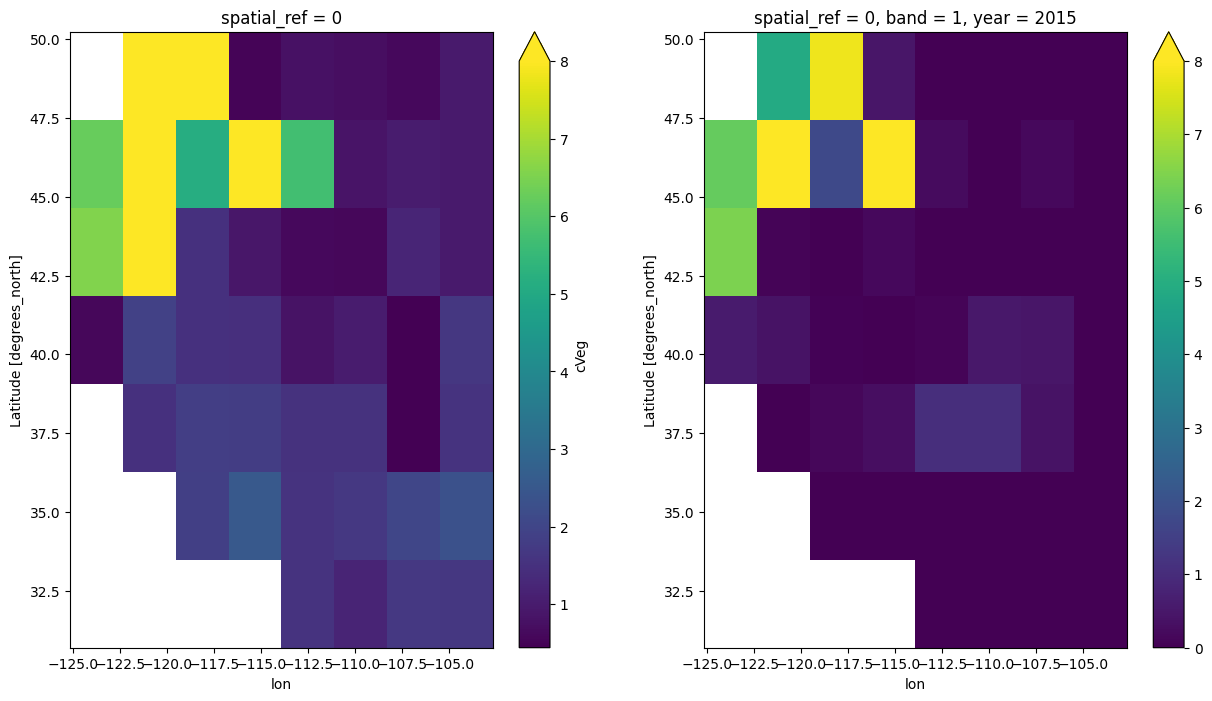

In [8]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
cveg[0:12*30,:,:].mean(dim='time').plot(vmax=8)
plt.subplot(1,2,2)
(cveg*FRF_reproj)[0:12*30,:,:].mean(dim='time').plot(vmax=8)

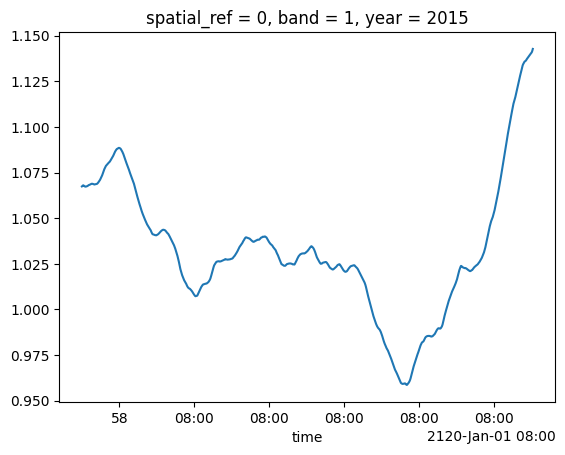

In [9]:
(cveg*FRF_reproj).rolling(time=12*10).mean().mean(dim=['lat','lon']).plot()

In [52]:
tseries_list

[<xarray.DataArray (year: 20)> Size: 160B
 array([3318.93671954, 3301.28864453, 3268.52197035, 3232.92680271,
        3257.15182389, 3266.8745467 , 3249.50842369, 3229.96139517,
        3221.02774807, 3209.33170606, 3205.00799849, 3204.72697131,
        3195.15781538, 3197.30951897, 3190.97722419, 3166.18497385,
        3158.3003236 , 3156.09223087, 3154.36622478, 3129.87095847])
 Coordinates:
     spatial_ref  int64 8B 0
     band         int64 8B 1
   * year         (year) int64 160B 2005 2006 2007 2008 ... 2021 2022 2023 2024,
 <xarray.DataArray (year: 20)> Size: 160B
 array([3871.65111783, 3891.56609432, 3936.97895247, 3970.48154068,
        3990.85587987, 4004.79991503, 4009.04844485, 4035.07900903,
        4037.59212643, 4042.02147639, 4106.40055491, 4138.28963639,
        4162.10183083, 4163.75060626, 4209.50056292, 4229.43248229,
        4214.01871385, 4194.24802529, 4164.49510525, 4165.57294373])
 Coordinates:
     spatial_ref  int64 8B 0
     band         int64 8B 1
   * year

In [ ]:
import pandas as pd

df_all_westwide = pd.read_csv("figure_data/figure_2/OurStudy_western_stocks.csv")
western_stocks = pd.read_csv("figure_data/figure_2/USFS_western_stocks.csv")
western_stocks = western_stocks.rename(columns={"Unnamed: 0": "year", "0": "live_biomass_MMT"})

In [ ]:
biomass_mean_west = df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).median()
biomass_min_west = (
    df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).quantile(0.025)
)
biomass_max_west = (
    df_all_westwide["live_biomass_MMT"].groupby(df_all_westwide["year"]).quantile(0.975)
)

biomass_mean_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).median()
)
biomass_min_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).quantile(0.025)
)
biomass_max_west_delta = (
    df_all_westwide["live_biomass_MMT_delta"].groupby(df_all_westwide["year"]).quantile(0.975)
)

# Li et al. 2025

In [6]:
# Load the .mat file
trend1 = scipy.io.loadmat(
    "/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/Li_2025/datasets/trendBC1016.mat"
)
trend2 = scipy.io.loadmat(
    "/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/Li_2025/datasets/trendBC1622.mat"
)
lat = scipy.io.loadmat(
    "/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/Li_2025/datasets/lat.mat"
)
lon = scipy.io.loadmat(
    "/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/raw_data/Li_2025/datasets/lon.mat"
)

western_states = maps.SHP_WESTERN

da_trend1 = xr.DataArray(
    trend1["trendBC1016"],
    dims=["lat", "lon"],  # specify dimension names
    coords={
        "lat": lat["lat"].squeeze(),
        "lon": lon["lon"].squeeze(),
    },
).rio.write_crs("EPSG:4326")
da_trend1 = da_trend1.rio.set_spatial_dims(x_dim="lon", y_dim="lat")

da_trend2 = xr.DataArray(
    trend2["trendBC1622"],
    dims=["lat", "lon"],  # specify dimension names
    coords={
        "lat": lat["lat"].squeeze(),
        "lon": lon["lon"].squeeze(),
    },
).rio.write_crs("EPSG:4326")
da_trend1 = da_trend1.rio.set_spatial_dims(x_dim="lon", y_dim="lat")


from shapely.geometry import Point

# Step 1: Bounding box clip (what you already have)
minx, miny, maxx, maxy = western_states.total_bounds
lon_mask = (da_trend1["lon"] >= minx) & (da_trend1["lon"] <= maxx)
lat_mask = (da_trend1["lat"] >= miny) & (da_trend1["lat"] <= maxy)
da_trend1_clipped = da_trend1.where(lon_mask & lat_mask, drop=True)
da_trend2_clipped = da_trend2.where(lon_mask & lat_mask, drop=True)

# Step 2: Create a mask for points inside western_states polygons
# Combine all geometries into one
from shapely.ops import unary_union

western_states_union = unary_union(western_states.geometry)

# Create 2D coordinate arrays
lons_2d, lats_2d = np.meshgrid(da_trend1_clipped["lon"].values, da_trend1_clipped["lat"].values)

# Check which points are inside the shapefile
mask = np.zeros(lons_2d.shape, dtype=bool)
for i in range(lons_2d.shape[0]):
    for j in range(lons_2d.shape[1]):
        point = Point(lons_2d[i, j], lats_2d[i, j])
        mask[i, j] = western_states_union.contains(point)

# Apply the mask
da_trend1_clipped = da_trend1_clipped.where(mask)
da_trend2_clipped = da_trend2_clipped.where(mask)

print(
    "Final clipped lat range:",
    da_trend1_clipped["lat"].min().values,
    "to",
    da_trend1_clipped["lat"].max().values,
)
print(
    "Final clipped lon range:",
    da_trend1_clipped["lon"].min().values,
    "to",
    da_trend1_clipped["lon"].max().values,
)

Final clipped lat range: 31.431642532348633 to 48.85219192504883
Final clipped lon range: -124.62535858154297 to -102.06051635742188


In [7]:
# Reproject FRF to WGS84 lat/lon (EPSG:4326)
# FRF_latlon = FRF.rio.reproject("EPSG:4326", resampling=Resampling.bilinear)

# Then reproject_match to snap to da_trend1's exact grid
# FRF_matched = FRF_latlon.rio.reproject_match(da_trend1_clipped, resampling=Resampling.bilinear)

In [8]:
# FRF_matched_clipped=FRF_matched.where(lon_mask & lat_mask, drop=True)

In [9]:
gridcell_m2 = 25000 * 25000
m2_per_ha = 10000
gridcell_ha = gridcell_m2 / m2_per_ha

In [10]:
trend1_westwide = (da_trend1_clipped * gridcell_ha / 1e6).sum(dim=["lat", "lon"])
trend2_westwide = (da_trend2_clipped * gridcell_ha / 1e6).sum(dim=["lat", "lon"])

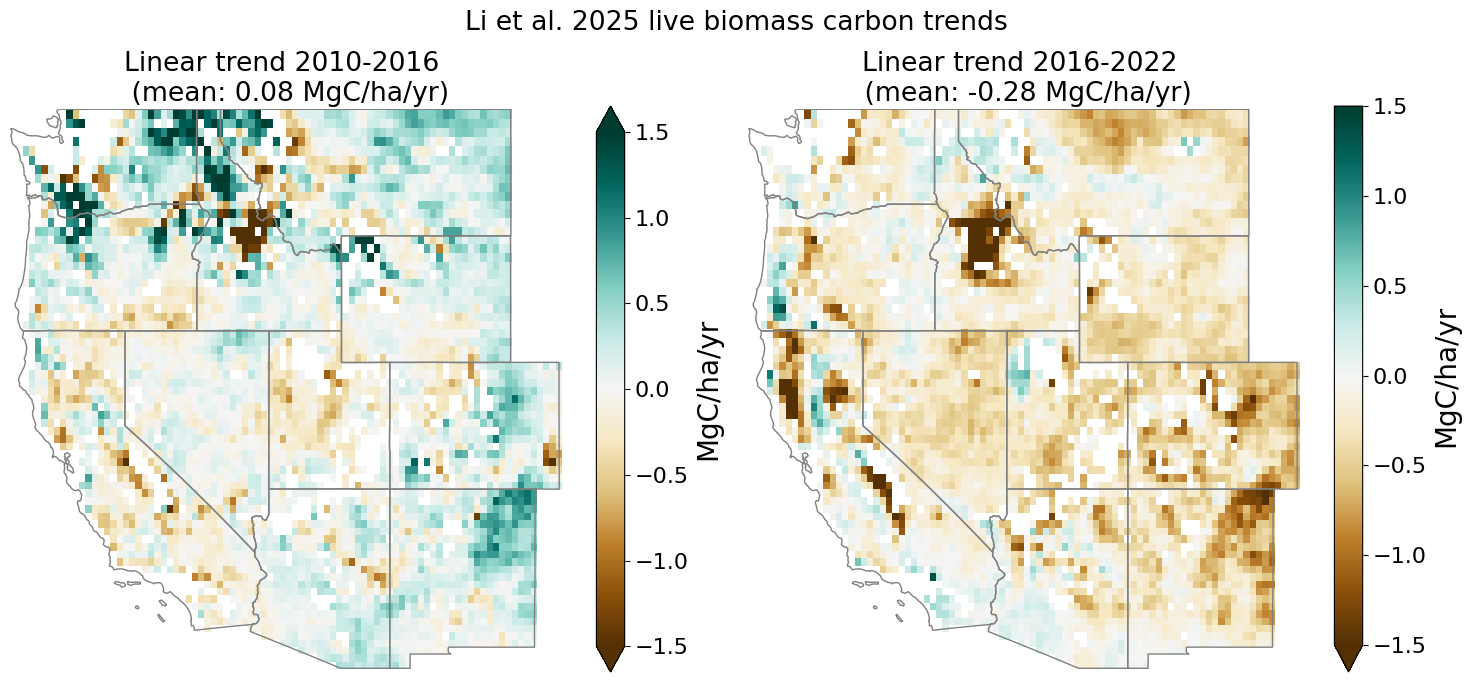

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
# .rio.clip(western_states.geometry).plot()
plt.subplot(1, 2, 1)
maps.plot_map(
    da_trend1_clipped,
    shp=western_states,
    latlon=False,
    cbar_label="MgC/ha/yr",
    cmap=plt.cm.BrBG,
    savefig=None,
    clims=[-1.5, 1.5],
    title="Linear trend 2010-2016 \n (mean: 0.08 MgC/ha/yr)",
    ax=ax[0],
)
# plt.xlim([-125,-102])
# plt.ylim([31,49.5])

plt.subplot(1, 2, 2)
maps.plot_map(
    da_trend2_clipped,
    shp=western_states,
    latlon=False,
    cbar_label="MgC/ha/yr",
    cmap=plt.cm.BrBG,
    savefig=None,
    clims=[-1.5, 1.5],
    title="Linear trend 2016-2022 \n (mean: -0.28 MgC/ha/yr)",
    ax=ax[1],
)
plt.suptitle("Li et al. 2025 live biomass carbon trends")
plt.tight_layout()
plt.savefig(dir_figures + "Li_2025_western.pdf")
# plt.xlim([-125,-102])
# plt.ylim([31,49.5])

In [12]:
ds_inputs = xr.open_dataset('/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/processed_data/data_on_ref_grid/1000m/'+
                            'all_variables.nc')
with open('figure_data/figure_2/target_crs.txt', "r") as f:
    text = f.read()

In [13]:
FRF=ds_inputs['forest_remaining_forest'].sel(year=2016)
FRF=FRF.rio.write_crs(text)

FRF_reprojected = FRF.rio.reproject(da_trend1_clipped.rio.crs)

# Rename dimensions to match
FRF_reprojected = FRF_reprojected.rename({'x': 'lon', 'y': 'lat'})

# Now interp_like will work
FRF_reprojected = FRF_reprojected.interp_like(da_trend1_clipped)

In [14]:
FRF2=ds_inputs['forest_remaining_forest'].sel(year=2021)
FRF2=FRF2.rio.write_crs(text)

FRF2_reprojected = FRF2.rio.reproject(da_trend1_clipped.rio.crs)

# Rename dimensions to match
FRF2_reprojected = FRF2_reprojected.rename({'x': 'lon', 'y': 'lat'})

# Now interp_like will work
FRF2_reprojected = FRF2_reprojected.interp_like(da_trend2_clipped)

In [15]:
da_trend1_clipped=da_trend1_clipped*FRF_reprojected/100
da_trend2_clipped=da_trend2_clipped*FRF2_reprojected/100

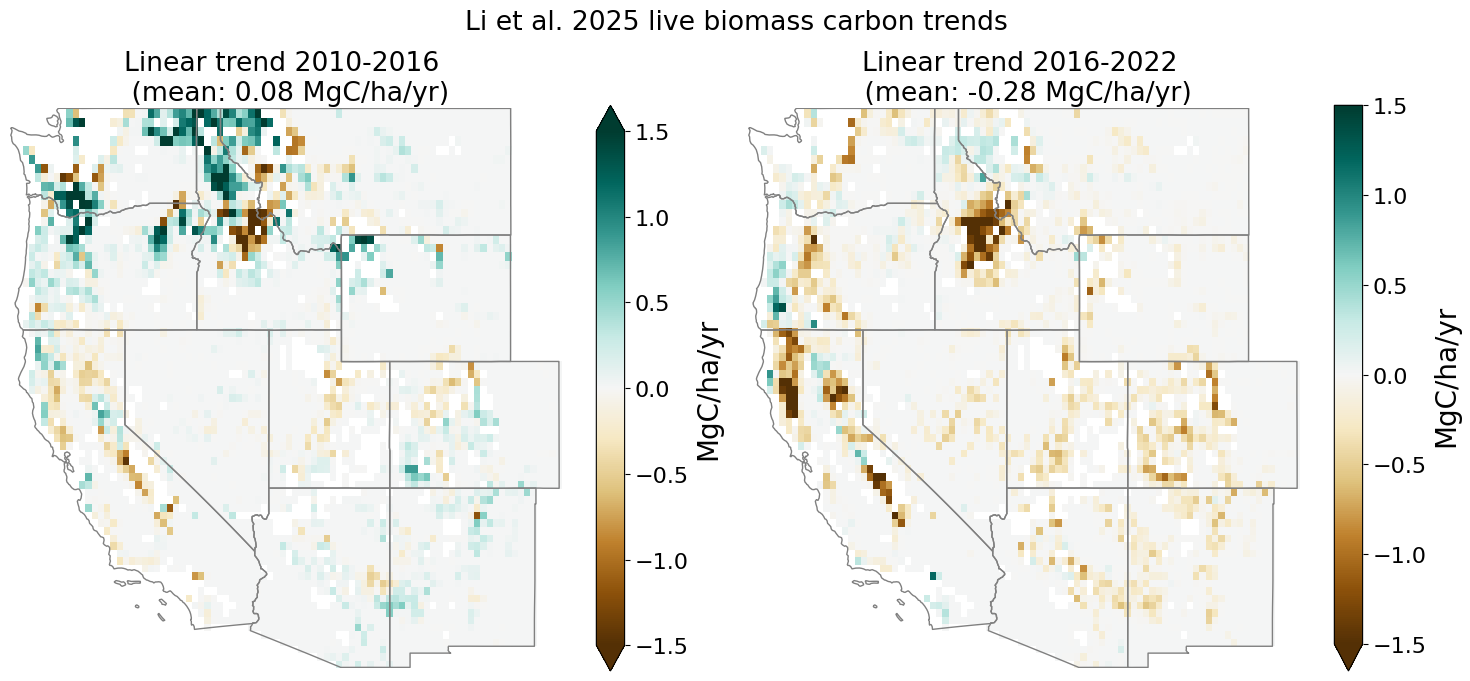

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
# .rio.clip(western_states.geometry).plot()
plt.subplot(1, 2, 1)
maps.plot_map(
    da_trend1_clipped,
    shp=western_states,
    latlon=False,
    cbar_label="MgC/ha/yr",
    cmap=plt.cm.BrBG,
    savefig=None,
    clims=[-1.5, 1.5],
    title="Linear trend 2010-2016 \n (mean: 0.08 MgC/ha/yr)",
    ax=ax[0],
)
# plt.xlim([-125,-102])
# plt.ylim([31,49.5])

plt.subplot(1, 2, 2)
maps.plot_map(
    da_trend2_clipped,
    shp=western_states,
    latlon=False,
    cbar_label="MgC/ha/yr",
    cmap=plt.cm.BrBG,
    savefig=None,
    clims=[-1.5, 1.5],
    title="Linear trend 2016-2022 \n (mean: -0.28 MgC/ha/yr)",
    ax=ax[1],
)
plt.suptitle("Li et al. 2025 live biomass carbon trends")
plt.tight_layout()
plt.savefig(dir_figures + "Li_2025_western.pdf")
# plt.xlim([-125,-102])
# plt.ylim([31,49.5])

In [17]:
trend1_westwide_FRF = (da_trend1_clipped * gridcell_ha / 1e6).sum(dim=["lat", "lon"])
trend2_westwide_FRF = (da_trend2_clipped * gridcell_ha / 1e6).sum(dim=["lat", "lon"])

In [18]:
print(np.nanmean(da_trend1_clipped))
print(np.nanmean(da_trend2_clipped))

0.02920098923174444
-0.08012252376545037


In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
plt.subplot(1, 2, 1)
maps.plot_map(
    mapdata * 10000 / 1000,
    shp=western_states,
    latlon=False,
    cbar_label="MgC/ha/yr",
    cmap=plt.cm.BrBG,
    savefig=None,
    clims=[-1.5, 1.5],
    ax=ax[0],
    # title="Linear trend 2010-2016 \n (mean: 0.08 MgC/ha/yr)",
)
plt.subplot(1, 2, 2)
tseries = (cbiotot_FRF * 990 * 990 / 1000 / 1e6).sum(dim=["x", "y"])
plt.plot(np.arange(2005, 2021), tseries)
plt.plot(
    np.arange(2005, 2021), tseries.rolling(year=5, center=True).mean(), linestyle="--"
)  # .plot()
# plt.plot(np.arange(2005,2021), (ds_west['cbiotot']*990*990/1000/1e6)[20:,0,:,:].sum(dim=['x','y']))
plt.axvspan(xmin=2005, xmax=2022, alpha=0.2, color="gray")
plt.ylabel("Western live biomass (MMT C)")
plt.tight_layout()
plt.savefig(dir_figures + "Liu_2025_western.pdf")

# Save data

In [29]:
tseries_list[40]

<xarray.DataArray (year: 20)> Size: 160B
array([6045.45812469, 6065.5234272 , 6073.15735663, 6091.93224487,
       6117.44675338, 6142.87480674, 6149.34849664, 6135.68309251,
       6149.23206084, 6163.68196973, 6174.30247214, 6151.55584956,
       6151.99646594, 6148.12314751, 6134.24113862, 6144.61516681,
       6160.30421538, 6177.93144635, 6181.35870933, 6190.74007879])
Coordinates:
    spatial_ref  int64 8B 0
    band         int64 8B 1
  * year         (year) int64 160B 2005 2006 2007 2008 ... 2021 2022 2023 2024

In [40]:
# Stack all CMIP6 anomaly time series and compute percentile envelope
cmip_anomalies = []
for i, fname in enumerate(fnames):
    print(i)
    tseries_comparison = tseries_list[i]
    if len(tseries_comparison)==20:
        anomaly = (tseries_comparison - tseries_comparison[0]) * 0.8
        cmip_anomalies.append(anomaly.values)

cmip_array = np.array(cmip_anomalies)  # shape: (n_models, n_times)
cmip_times = tseries_list[1].year.values

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186


In [41]:
import xarray as xr

da = xr.DataArray(
    cmip_array,
    dims=["ensemble_member", "year"],
    coords={"year": cmip_times, "ensemble_member": range(len(cmip_array))},
)
df = da.to_dataset(name="change_since_2005")
df.to_netcdf("figure_data/figure_5/CMIP_tseries2_FRF.nc")

In [5]:
tseries = (cbiotot * 990 * 990 / 1000 / 1e6).sum(dim=["x", "y"])
tseries_df = tseries.to_dataset(name="Liu_biomass")
tseries_df.to_netcdf("figure_data/figure_5/Liu_tseries.nc")

tseries = (cbiotot_FRF * 990 * 990 / 1000 / 1e6).sum(dim=["x", "y"])
tseries_df = tseries.to_dataset(name="Liu_biomass")
tseries_df.to_netcdf("figure_data/figure_5/Liu_tseries_FRF.nc")

In [21]:
import pandas as pd

trends_df = pd.DataFrame(
    [
        {"year_start": 2010, "year_end": 2016, "trend": trend1_westwide.values},
        {"year_start": 2016, "year_end": 2022, "trend": trend2_westwide.values},
    ]
)
trends_df.to_csv("figure_data/figure_5/Li_trends.csv")

trends_df = pd.DataFrame(
    [
        {"year_start": 2010, "year_end": 2016, "trend": trend1_westwide_FRF.values},
        {"year_start": 2016, "year_end": 2022, "trend": trend2_westwide_FRF.values},
    ]
)
trends_df.to_csv("figure_data/figure_5/Li_trends_FRF.csv")